In [1]:
import os
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical


In [2]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [3]:
zip_path = "digit-recognizer.zip"
extract_folder = "digit_data"

if os.path.exists(zip_path) and not os.path.exists(extract_folder):
    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extractall(extract_folder)

train_path = os.path.join(extract_folder, "train.csv")
test_path = os.path.join(extract_folder, "test.csv")


In [4]:
if not os.path.exists(train_path):
    train_path = "train.csv"
if not os.path.exists(test_path):
    test_path = "test.csv"



In [9]:

import pandas as pd
import os

# Always good to check where your notebook is running
print("Current working directory:")
print(os.getcwd())

# Use FULL path (based on what you gave)
train_path = "data/train.csv"
test_path = "data/test.csv"

# Load the data
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Check if loaded correctly
print("\nTrain shape:", train_df.shape)
print("Test shape :", test_df.shape)

train_df.head()

Current working directory:
/Users/keerthanalingala/Documents/tanvi

Train shape: (42000, 785)
Test shape : (28000, 784)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
# -----------------------------
# 5. Separate features and labels
# -----------------------------
labels = train_df["label"].copy()
features = train_df.drop(columns=["label"]).copy()

print("Features shape:", features.shape)
print("Labels shape  :", labels.shape)

Features shape: (42000, 784)
Labels shape  : (42000,)


In [11]:
# -----------------------------
# 6. Check missing values
# -----------------------------
print("Missing values in training features:", features.isnull().sum().sum())
print("Missing values in test data:", test_df.isnull().sum().sum())

Missing values in training features: 0
Missing values in test data: 0


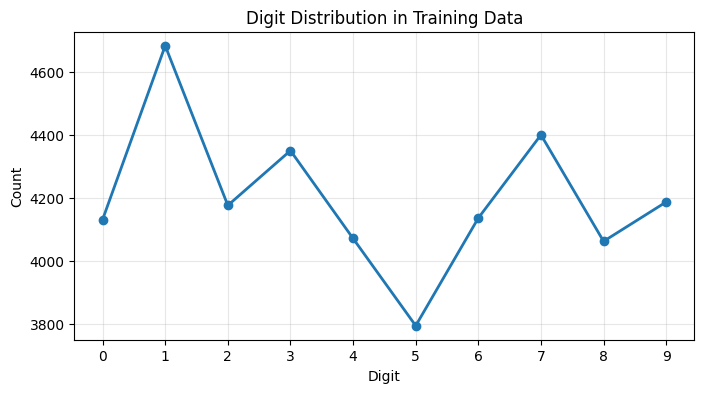

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64


In [12]:

#  Class distribution
# Different from the Kaggle bar plot:
# using a line plot with markers
digit_counts = labels.value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.plot(digit_counts.index, digit_counts.values, marker="o", linewidth=2)
plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Count")
plt.title("Digit Distribution in Training Data")
plt.grid(alpha=0.3)
plt.show()

print(digit_counts)

In [13]:
# -----------------------------
# 8. Normalize pixel values
# -----------------------------
features = features.astype("float32") / 255.0
test_df = test_df.astype("float32") / 255.0

In [14]:
# 9. Reshape images
# CNN expects: (28, 28, 1)
X = features.values.reshape(-1, 28, 28, 1)
X_test = test_df.values.reshape(-1, 28, 28, 1)

print("X shape     :", X.shape)
print("X_test shape:", X_test.shape)

X shape     : (42000, 28, 28, 1)
X_test shape: (28000, 28, 28, 1)


In [16]:
# 10. One-hot encode labels
y = to_categorical(labels, num_classes=10)
print("Encoded y shape:", y.shape)

Encoded y shape: (42000, 10)


In [17]:
# 11. Train-validation split
# -----------------------------
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.10, random_state=SEED, stratify=labels
)

print("Training set   :", X_train.shape, y_train.shape)
print("Validation set :", X_valid.shape, y_valid.shape)

Training set   : (37800, 28, 28, 1) (37800, 10)
Validation set : (4200, 28, 28, 1) (4200, 10)


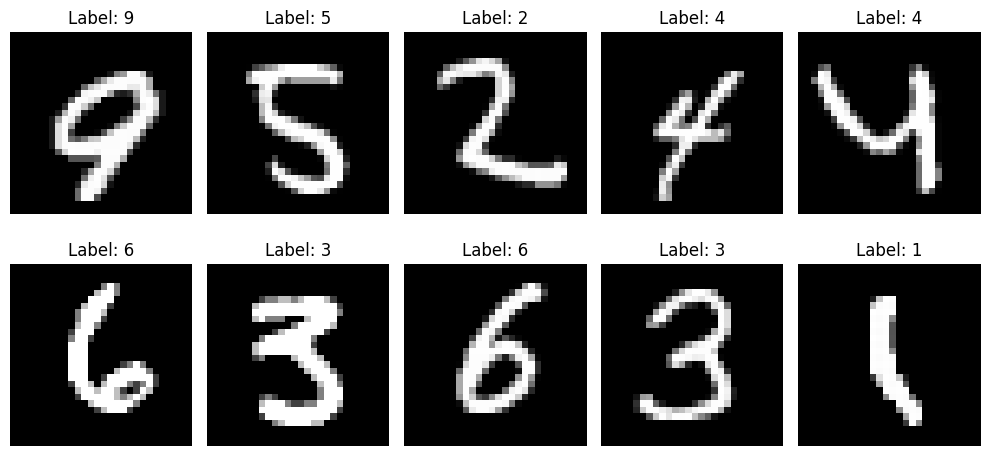

In [18]:
# 12. Show sample images
# -----------------------------
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.flatten()

sample_indices = np.random.choice(len(X_train), 10, replace=False)

for ax, idx in zip(axes, sample_indices):
    ax.imshow(X_train[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {np.argmax(y_train[idx])}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# -----------------------------
# 13. Build the CNN model
# Same core method, cleaner formatting
# -----------------------------
model = Sequential([
    Conv2D(32, (5, 5), activation="relu", padding="same", input_shape=(28, 28, 1)),
    Conv2D(32, (5, 5), activation="relu", padding="same"),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.50),
    Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 887,530 (3.39 MB)

 Trainable params: 887,530 (3.39 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# -----------------------------
# 13. Build the CNN model
# Same core method, cleaner formatting
# -----------------------------
model = Sequential([
    Conv2D(32, (5, 5), activation="relu", padding="same", input_shape=(28, 28, 1)),
    Conv2D(32, (5, 5), activation="relu", padding="same"),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.50),
    Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 887,530 (3.39 MB)

 Trainable params: 887,530 (3.39 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# -----------------------------
# 14. Compile the model
# -----------------------------
optimizer = RMSprop(
    learning_rate=0.001,
    rho=0.9,
    epsilon=1e-08
)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
# -----------------------------
# 15. Learning rate scheduler
# -----------------------------
lr_scheduler = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-5
)

In [24]:
# -----------------------------
# 17. Train the model
# For testing: set EPOCHS = 3
# For full replication: set EPOCHS = 30

# -----------------------------
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create augmentation object
augmentor = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Fit it on training data
augmentor.fit(X_train)

EPOCHS = 30
BATCH_SIZE = 86

history = model.fit(
    augmentor.flow(X_train, y_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(X_valid, y_valid),
    steps_per_epoch=X_train.shape[0] // BATCH_SIZE,
    callbacks=[lr_scheduler],
    verbose=2
)

Epoch 1/30
439/439 - 30s - 68ms/step - accuracy: 0.8573 - loss: 0.4417 - val_accuracy: 0.9776 - val_loss: 0.0863 - learning_rate: 1.0000e-03
Epoch 2/30
439/439 - 1s - 2ms/step - accuracy: 0.9535 - loss: 0.2171 - val_accuracy: 0.9788 - val_loss: 0.0715 - learning_rate: 1.0000e-03
Epoch 3/30
439/439 - 30s - 68ms/step - accuracy: 0.9600 - loss: 0.1328 - val_accuracy: 0.9874 - val_loss: 0.0487 - learning_rate: 1.0000e-03
Epoch 4/30
439/439 - 1s - 2ms/step - accuracy: 0.9651 - loss: 0.1851 - val_accuracy: 0.9845 - val_loss: 0.0494 - learning_rate: 1.0000e-03
Epoch 5/30
439/439 - 29s - 67ms/step - accuracy: 0.9716 - loss: 0.0973 - val_accuracy: 0.9879 - val_loss: 0.0377 - learning_rate: 1.0000e-03
Epoch 6/30
439/439 - 1s - 2ms/step - accuracy: 0.9767 - loss: 0.0881 - val_accuracy: 0.9864 - val_loss: 0.0425 - learning_rate: 1.0000e-03
Epoch 7/30
439/439 - 30s - 69ms/step - accuracy: 0.9753 - loss: 0.0819 - val_accuracy: 0.9905 - val_loss: 0.0341 - learning_rate: 1.0000e-03
Epoch 8/30
439/439 

In [25]:
# -----------------------------
# 18. Training history plots
# Different presentation from the original
# -----------------------------
history_df = pd.DataFrame(history.history)
history_df.head()

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.857268,0.441654,0.977619,0.086295,0.001
1,0.953488,0.217121,0.978810,0.071511,0.001
2,0.959962,0.132846,0.987381,0.048731,0.001
3,0.965116,0.185067,0.984524,0.049382,0.001
4,0.971629,0.097330,0.987857,0.037689,0.001


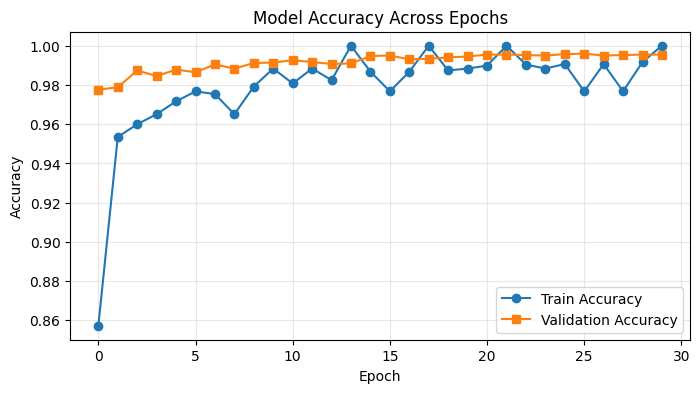

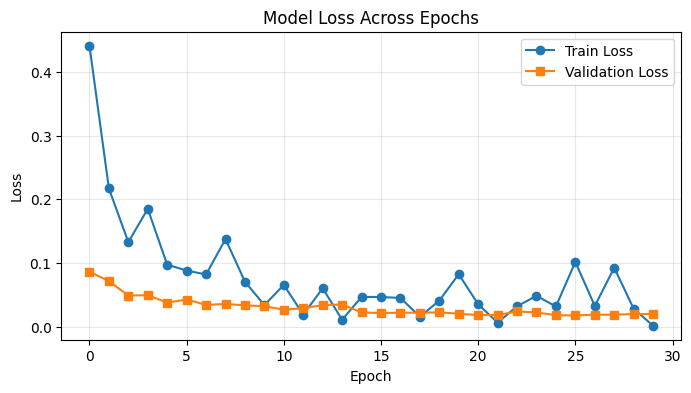

In [26]:
# Accuracy curve
plt.figure(figsize=(8, 4))
plt.plot(history_df["accuracy"], marker="o", label="Train Accuracy")
plt.plot(history_df["val_accuracy"], marker="s", label="Validation Accuracy")
plt.title("Model Accuracy Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(history_df["loss"], marker="o", label="Train Loss")
plt.plot(history_df["val_loss"], marker="s", label="Validation Loss")
plt.title("Model Loss Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [27]:
# -----------------------------
# 19. Validation predictions
# -----------------------------
valid_probabilities = model.predict(X_valid, verbose=0)
valid_predictions = np.argmax(valid_probabilities, axis=1)


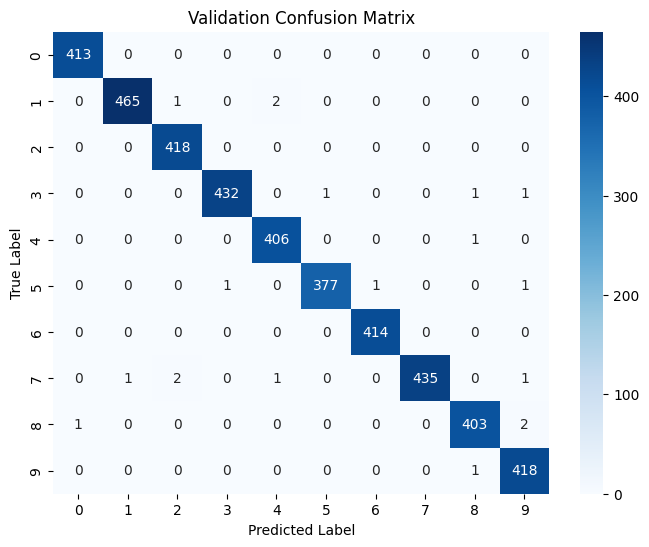

In [29]:
# -----------------------------
# 20. Confusion matrix
# Different style: seaborn heatmap
# -----------------------------
# -----------------------------
# Generate predictions
# -----------------------------
valid_probabilities = model.predict(X_valid, verbose=0)

# Predicted labels
valid_predictions = valid_probabilities.argmax(axis=1)

# True labels
valid_true = y_valid.argmax(axis=1)
cm = confusion_matrix(valid_true, valid_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [30]:
# -----------------------------
# 21. Classification report
# -----------------------------
print(classification_report(valid_true, valid_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       413
           1       1.00      0.99      1.00       468
           2       0.99      1.00      1.00       418
           3       1.00      0.99      1.00       435
           4       0.99      1.00      1.00       407
           5       1.00      0.99      0.99       380
           6       1.00      1.00      1.00       414
           7       1.00      0.99      0.99       440
           8       0.99      0.99      0.99       406
           9       0.99      1.00      0.99       419

    accuracy                           1.00      4200
   macro avg       1.00      1.00      1.00      4200
weighted avg       1.00      1.00      1.00      4200



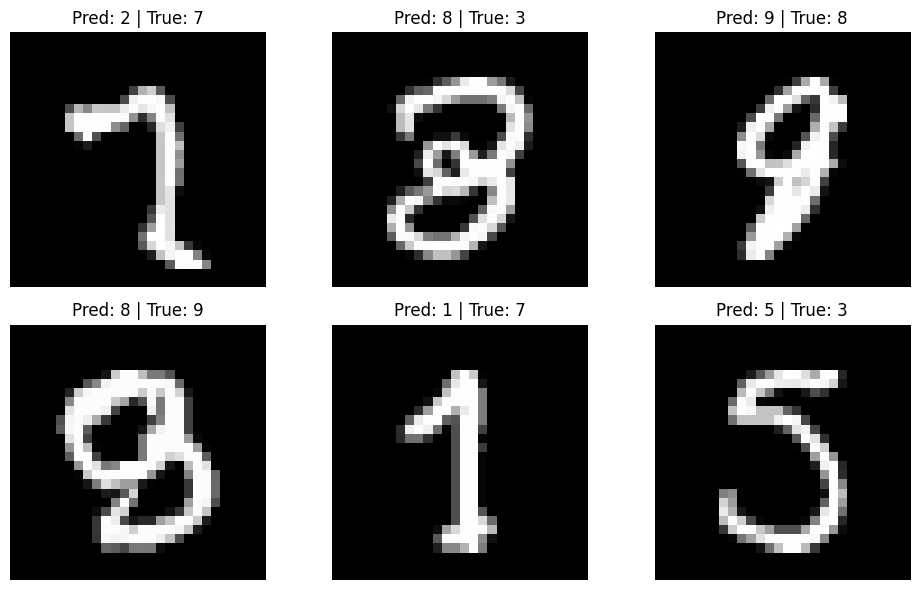

In [31]:
# -----------------------------
# 22. Show difficult prediction errors
# -----------------------------
incorrect_mask = valid_predictions != valid_true

X_errors = X_valid[incorrect_mask]
pred_errors = valid_predictions[incorrect_mask]
true_errors = valid_true[incorrect_mask]
prob_errors = valid_probabilities[incorrect_mask]

# Confidence of predicted class
pred_confidence = np.max(prob_errors, axis=1)

# Confidence of the true class
true_confidence = prob_errors[np.arange(len(prob_errors)), true_errors]

# Gap between wrong prediction confidence and true label confidence
confidence_gap = pred_confidence - true_confidence

# Take the 6 most confident wrong predictions
top_error_idx = np.argsort(confidence_gap)[-6:]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()

for plot_idx, error_idx in enumerate(top_error_idx):
    axes[plot_idx].imshow(X_errors[error_idx].reshape(28, 28), cmap="gray")
    axes[plot_idx].set_title(
        f"Pred: {pred_errors[error_idx]} | True: {true_errors[error_idx]}"
    )
    axes[plot_idx].axis("off")

plt.tight_layout()
plt.show()

In [32]:
# -----------------------------
# 23. Predict test set labels
# -----------------------------
test_probabilities = model.predict(X_test, verbose=0)
test_predictions = np.argmax(test_probabilities, axis=1)

print("Prediction shape:", test_predictions.shape)
print(test_predictions[:10])

Prediction shape: (28000,)
[2 0 9 0 3 7 0 3 0 3]


In [33]:
# -----------------------------
# 24. Create submission file
# -----------------------------
submission = pd.DataFrame({
    "ImageId": np.arange(1, len(test_predictions) + 1),
    "Label": test_predictions
})

submission.to_csv("cnn_digit_submission.csv", index=False)
print("Submission file saved as: cnn_digit_submission.csv")
submission.head()

Submission file saved as: cnn_digit_submission.csv


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3


In [34]:
# -----------------------------
# 25. Final validation score
# -----------------------------
final_loss, final_accuracy = model.evaluate(X_valid, y_valid, verbose=0)
print(f"Validation Loss     : {final_loss:.4f}")
print(f"Validation Accuracy : {final_accuracy:.4f}")

Validation Loss     : 0.0197
Validation Accuracy : 0.9955
